<a href="https://colab.research.google.com/github/vinay2142070/AI_ML_Research/blob/main/Optimizers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install numpy
!pip install matplotlib

**Formula for MSE**

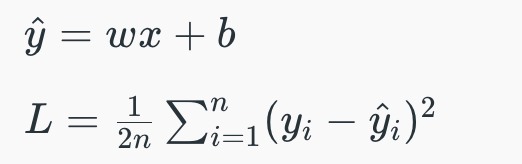

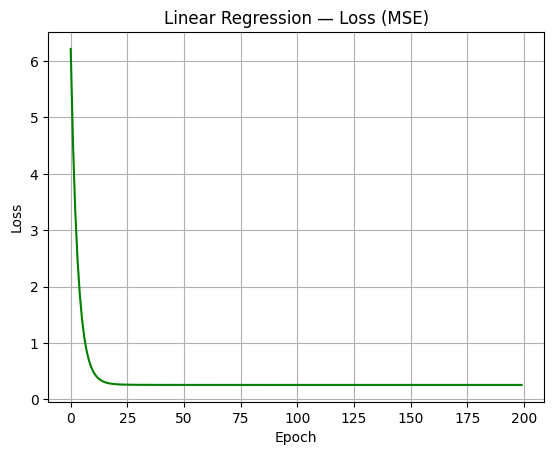

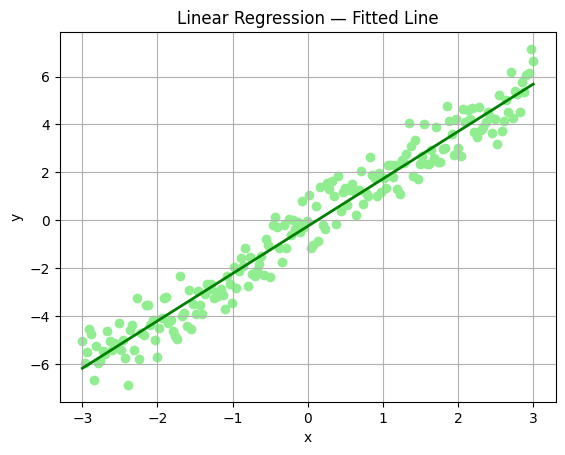

In [3]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

n = 200
X = np.linspace(-3, 3, n).reshape(-1, 1)
y = 2 * X.ravel() - 0.3 + 0.7 * np.random.randn(n)

w, b = 0.0, 0.0
lr = 0.05
epochs = 200
losses = []

for _ in range(epochs):
    preds = w * X.ravel() + b
    err = preds - y
    loss = (err**2).mean() / 2
    losses.append(loss)
    dw = (X.ravel() * err).mean()
    db = err.mean()
    w -= lr * dw
    b -= lr * db

plt.figure()
plt.plot(losses, color="green")
plt.title("Linear Regression — Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

plt.figure()
plt.scatter(X, y, color="lightgreen")
idx = np.argsort(X.ravel())
plt.plot(X[idx], (w * X + b)[idx], color="green", linewidth=2)
plt.title("Linear Regression — Fitted Line")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

**Formula: Loss function(BCE) for Logistic Regression**
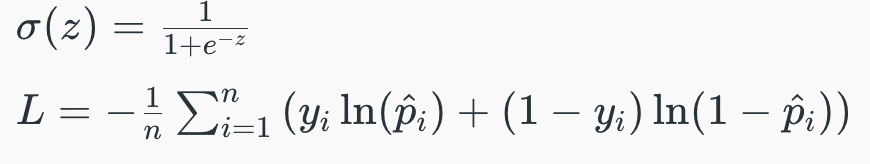

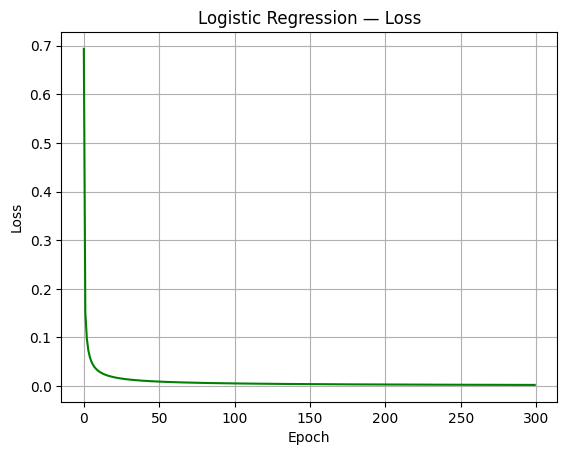

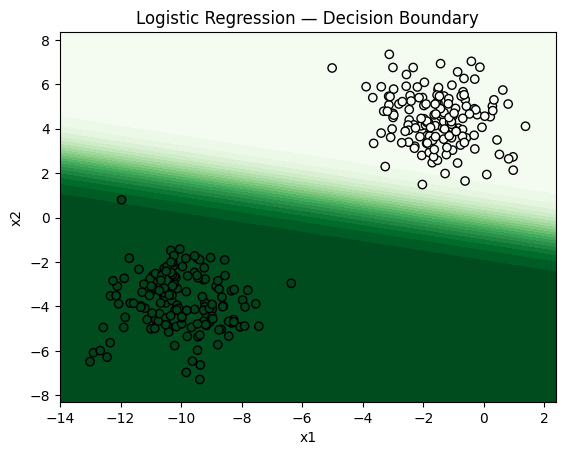

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
np.random.seed(1)

X, y = make_blobs(n_samples=300, centers=2, cluster_std=1.2)
w = np.zeros(X.shape[1])
b = 0.0
lr = 0.2
losses = []

def sigmoid(z): return 1 / (1 + np.exp(-z))

for _ in range(300):
    z = X.dot(w) + b
    p = sigmoid(z)
    loss = -(y * np.log(p + 1e-12) + (1 - y) * np.log(1 - p + 1e-12)).mean()
    losses.append(loss)
    dw = X.T.dot(p - y) / len(X)
    db = (p - y).mean()
    w -= lr * dw
    b -= lr * db

plt.figure()
plt.plot(losses, color="green")
plt.title("Logistic Regression — Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200)
)
grid = np.c_[xx.ravel(), yy.ravel()]
probs = sigmoid(grid.dot(w) + b).reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, probs, 20, cmap="Greens")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="Greens", edgecolor="black")
plt.title("Logistic Regression — Decision Boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()